# ChameleonNLP — Explainable Clinical NLP Pipeline

**Dataset:** 10,000 synthetic chest CT reports | 18 pathology classes | Kaggle T4 GPU

---

This notebook builds a complete, end-to-end clinical NLP pipeline in three modules:

| Module | What it does |
|--------|-------------|
| **Module 1** | Load the dataset, parse report sections, clean text, encode labels, split data |
| **Module 2** | Fine-tune BioBERT for 18-class pathology classification with class-weighted loss |
| **Module 3** | Extract clinical entities (findings, anatomy, severity, measurements) using regex NER |



## Install Libraries


In [1]:
!pip install -q transformers accelerate
!pip install -q sentence-transformers faiss-cpu
!pip install -q rouge-score
print('Done.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 66.9 MB/s eta 0:00:00
Done.


## Imports & Environment Setup

In [2]:
import os, re, json, warnings, pickle, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'numpy   : {np.__version__}')
print(f'pandas  : {pd.__version__}')
print(f'torch   : {torch.__version__}')
print(f'device  : {DEVICE}')
print('All imports OK.')

numpy   : 2.0.2
pandas  : 2.3.3
torch   : 2.9.0+cu126
device  : cuda
All imports OK.


---
# Module 1 
## Load & Preprocess

This module takes the raw CSV and produces three clean, stratified splits ready for training.

**Dataset structure:**
- `Pathology` — the label column, one of 18 class names
- `Report` — the full CT report text, structured with `**SECTION:**` headers

**Steps in this module:**
1. Load the CSV and inspect class counts
2. Parse `**FINDINGS:**` and `**IMPRESSION:**` sections from raw report text
3. Build label mappings and clean the text
4. Split into train / val / test sets (70 / 15 / 15, stratified)
5. EDA: visualise class distribution and report lengths

## Load Data

Loads the dataset from the input directory

**What to check in the output:**
- Shape should be `(10000, 2)` — 10,000 reports, 2 columns
- The `value_counts()` output immediately reveals the class imbalance: 5,000 Healthy vs ~292 per disease class

In [3]:
KAGGLE_DIR = '/kaggle/input/datasets/satviktripathib/chameleon-radiology-reports-dataset'
LOCAL_DIR  = './'
base       = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else LOCAL_DIR
csv_files  = glob.glob(os.path.join(base, '*.csv'))

if not csv_files:
    raise FileNotFoundError(f'No CSV found in {base}. Upload your file.')

df_raw = pd.read_csv(csv_files[0])
print(f'File   : {csv_files[0]}')
print(f'Shape  : {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
print()
print('Pathology counts:')
print(df_raw['Pathology'].value_counts().to_string())

File   : /kaggle/input/datasets/satviktripathib/chameleon-radiology-reports-dataset/Chameleon_radiology_reports.csv
Shape  : (10000, 2)
Columns: ['Pathology', 'Report']

Pathology counts:
Pathology
Healthy                                 5000
Tuberculosis                             304
Benign Nodules                           304
Pneumonia (lobular, fungal pnemonia)     304
Bronchitis                               292
Covid19                                  292
Pulmonary Embolism (PE)                  292
Emphysema                                292
Bronchiectasis                           292
Metastatic Nodule                        292
Pleural Effusion                         292
Non-Small Cell Lung Cancer               292
Adenocarcinoma                           292
Large Hodgkin Lymphoma                   292
Calcified Granulomas                     292
Aspergilloma                             292
Sarcoidosis                              292
Pulmonary Fibrosis                   

## Parse Report Sections

Each raw report contains multiple sections separated by bold markdown headers like `**FINDINGS:**`. This cell extracts just the two sections we need for modelling.

**How the parser works:**
- Two regex patterns with `re.DOTALL` (so `.` matches newlines across paragraphs) and `re.IGNORECASE` capture the FINDINGS and IMPRESSION blocks
- A `clean()` helper strips the bold markers, removes bullet point characters, and collapses whitespace into continuous prose
- Reports with empty or near-empty findings sections are kept for now, and will be filtered later

**Expected output:** ~8,195 non-empty findings out of 10,000 raw reports. The ~1,805 that don't parse cleanly are structurally malformed or too sparse to be useful.

In [4]:
def parse_sections(text):
    if not isinstance(text, str):
        return {'findings': '', 'impression': ''}
    findings_m = re.search(
        r'\*\*FINDINGS:\*\*\s*(.*?)(?=\*\*IMPRESSION:\*\*|\Z)',
        text, re.DOTALL | re.IGNORECASE
    )
    impression_m = re.search(
        r'\*\*IMPRESSION:\*\*\s*(.*?)(?=---\s*$|\Z)',
        text, re.DOTALL | re.IGNORECASE
    )
    def clean(s):
        if not s: return ''
        s = re.sub(r'\*\*[^*]+\*\*\s*:?\s*', ' ', s)
        s = re.sub(r'^[-•]\s*', '', s, flags=re.MULTILINE)
        return re.sub(r'\s+', ' ', s).strip()
    return {
        'findings'  : clean(findings_m.group(1)   if findings_m   else ''),
        'impression': clean(impression_m.group(1)  if impression_m else '')
    }

parsed = df_raw['Report'].apply(parse_sections).apply(pd.Series)
df_raw = pd.concat([df_raw, parsed], axis=1)

print(f'Non-empty findings  : {(df_raw["findings"] != "").sum():,}')
print(f'Non-empty impression: {(df_raw["impression"] != "").sum():,}')
print()
print('Sample findings (first 200 chars):')
print(df_raw['findings'].iloc[0][:200])

Non-empty findings  : 8,195
Non-empty impression: 8,193

Sample findings (first 200 chars):
- The central airways are patent. No focal consolidation, pleural effusion, or pneumothorax is observed. No suspicious pulmonary nodules identified. - Pulmonary arteries are patent with no filling def


## Build Labels & Clean Text

Two things happen here that must run **before** the train/val/test split:

**Label encoding:**
Class names are sorted alphabetically before mapping to integers — this makes the mapping deterministic and identical across every run. Class 0 is always Adenocarcinoma, Class 8 is always Healthy, Class 17 is always Tuberculosis.

The `NaN in label_idx` check is a sanity gate — any typo or whitespace mismatch in the original CSV would produce null labels that silently corrupt training. It must be 0.

**Text cleaning:**
Strips remaining bold markers, bullet points, and excess whitespace from the findings and impression text. Reports with fewer than 30 characters of cleaned findings text are dropped as too sparse to be useful.

**Expected output:** 8,195 rows after filtering, all 18 classes present, zero NaN labels.

In [5]:
# --- Label mapping ---
PATHOLOGIES = sorted(df_raw['Pathology'].unique().tolist())
NUM_LABELS  = len(PATHOLOGIES)
path_to_idx = {p: i for i, p in enumerate(PATHOLOGIES)}
idx_to_path = {i: p for p, i in path_to_idx.items()}

# Add label_idx to df_raw NOW before any splitting
df_raw['label_idx'] = df_raw['Pathology'].map(path_to_idx)

print(f'Classes: {NUM_LABELS}')
print(f'NaN in label_idx: {df_raw["label_idx"].isna().sum()}  <- must be 0')
print()
for i, p in enumerate(PATHOLOGIES):
    print(f'  [{i:>2}] {p}')

# --- Text cleaning ---
def clean_text(text):
    if not isinstance(text, str) or not text.strip(): return ''
    text = re.sub(r'\*\*[^*]+\*\*\s*:?\s*', ' ', text)
    text = re.sub(r'^[-•]\s+', '', text, flags=re.MULTILINE)
    return re.sub(r'\s+', ' ', text).strip()

df_raw['findings_clean']   = df_raw['findings'].apply(clean_text)
df_raw['impression_clean'] = df_raw['impression'].apply(clean_text)

# Keep only rows with enough findings text
df = df_raw[df_raw['findings_clean'].str.len() > 30].copy().reset_index(drop=True)
print(f'\nRows after filtering: {len(df):,}')
print(f'Sample cleaned findings: {df["findings_clean"].iloc[0][:120]}')

Classes: 18
NaN in label_idx: 0  <- must be 0

  [ 0] Adenocarcinoma
  [ 1] Aspergilloma
  [ 2] Benign Nodules
  [ 3] Bronchiectasis
  [ 4] Bronchitis
  [ 5] Calcified Granulomas
  [ 6] Covid19
  [ 7] Emphysema
  [ 8] Healthy
  [ 9] Large Hodgkin Lymphoma
  [10] Metastatic Nodule
  [11] Non-Small Cell Lung Cancer
  [12] Pleural Effusion
  [13] Pneumonia (lobular, fungal pnemonia)
  [14] Pulmonary Embolism (PE)
  [15] Pulmonary Fibrosis
  [16] Sarcoidosis
  [17] Tuberculosis

Rows after filtering: 8,195
Sample cleaned findings: The central airways are patent. No focal consolidation, pleural effusion, or pneumothorax is observed. No suspicious pul


## Data Split: Train / Validation / Test Split (70 / 15 / 15)

Splits the 8,195 usable reports into three sets using a two-step approach:
1. Split off 30% as a temporary holdout
2. Split that holdout 50/50 into val and test

**Why `stratify=df['Pathology']`?**

Without stratification, a random split on an imbalanced dataset can concentrate all examples of a rare class into one split and leave another blind to it. Stratification guarantees every class maintains its proportional representation across all three sets.

The assertions at the end verify that all 18 classes are present in both train and val — if either assertion fails, the split has gone wrong and you should not continue.

In [6]:
df_train, df_temp = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['Pathology']
)
df_val, df_test = train_test_split(
    df_temp, test_size=0.50, random_state=SEED, stratify=df_temp['Pathology']
)
df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

print(f'Train : {len(df_train):,}')
print(f'Val   : {len(df_val):,}')
print(f'Test  : {len(df_test):,}')
print(f'\nClasses in train: {sorted(df_train["label_idx"].unique().tolist())}')

assert len(df_train['label_idx'].unique()) == NUM_LABELS, 'ERROR: missing classes in train!'
assert len(df_val['label_idx'].unique())   == NUM_LABELS, 'ERROR: missing classes in val!'
print('\nAll 18 classes present in every split. Ready to train.')

Train : 5,736
Val   : 1,229
Test  : 1,230

Classes in train: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

All 18 classes present in every split. Ready to train.


## Class Distribution

Visualises how many reports belong to each pathology class. Two charts:
- **Left:** Horizontal bar chart sorted by count, colour-coded by frequency tier (green ≥1000, orange 200–999, red <200)
- **Right:** Pie chart showing the Healthy vs Disease split at the top level

**What this tells us:**
Healthy accounts for 59.9% of the working dataset. The rarest class (Sarcoidosis) has just 152 reports — a **32:1 ratio** against Healthy. A naive model that always predicts Healthy would achieve 59.9% accuracy while identifying zero disease cases. This is why Module 2 uses class-weighted loss.

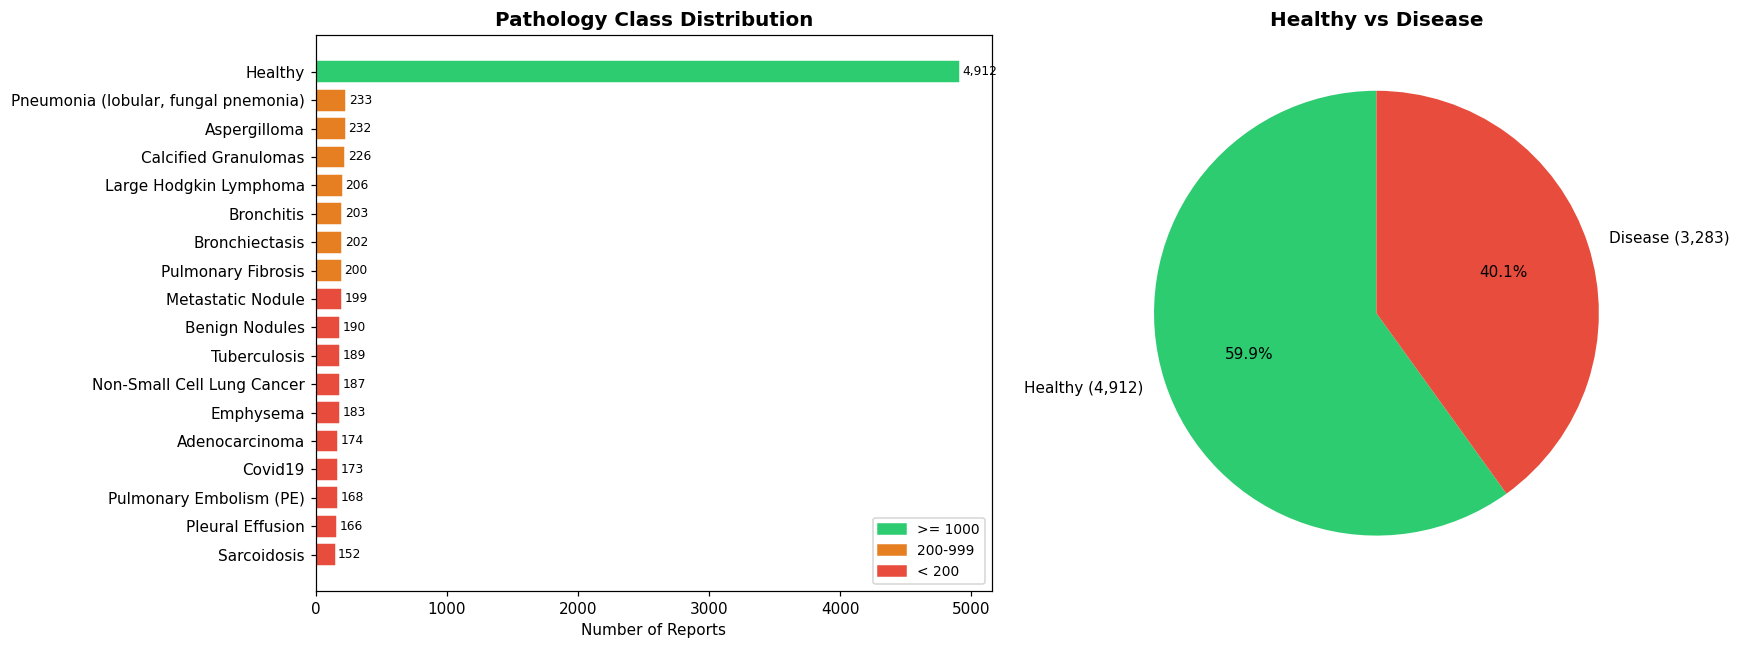

Healthy=5000, each disease=292-304. Class weighting will fix this imbalance.


In [7]:
counts = df['Pathology'].value_counts().sort_values(ascending=True)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['#2ecc71' if v >= 1000 else '#e67e22' if v >= 200 else '#e74c3c' for v in counts.values]
bars = axes[0].barh(counts.index, counts.values, color=colors, edgecolor='white')
axes[0].set_title('Pathology Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Reports')
for bar, val in zip(bars, counts.values):
    axes[0].text(val + 20, bar.get_y() + bar.get_height()/2, f'{val:,}', va='center', fontsize=8)
axes[0].legend(handles=[
    mpatches.Patch(color='#2ecc71', label='>= 1000'),
    mpatches.Patch(color='#e67e22', label='200-999'),
    mpatches.Patch(color='#e74c3c', label='< 200'),
], fontsize=9)

healthy_n = (df['Pathology'] == 'Healthy').sum()
axes[1].pie([healthy_n, len(df)-healthy_n],
            labels=[f'Healthy ({healthy_n:,})', f'Disease ({len(df)-healthy_n:,})'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Healthy vs Disease', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distribution.png', bbox_inches='tight')
plt.show()
print('Healthy=5000, each disease=292-304. Class weighting will fix this imbalance.')

## Report Lengths

Plots the word count distribution for both the Findings and Impression sections, with a red dashed line at the median.

**Key stats from the output:**
- Findings: median **116 words**, std 20, max 274 — consistently structured across all 18 classes
- Impression: median **45 words**, std 21 — short clinical summaries

**Why the max matters:** BioBERT's context window is 512 tokens (~380–400 words). At a maximum of 274 words, no report will be truncated during tokenisation — the model sees every word in full, which is a meaningful advantage over many real-world clinical NLP tasks.

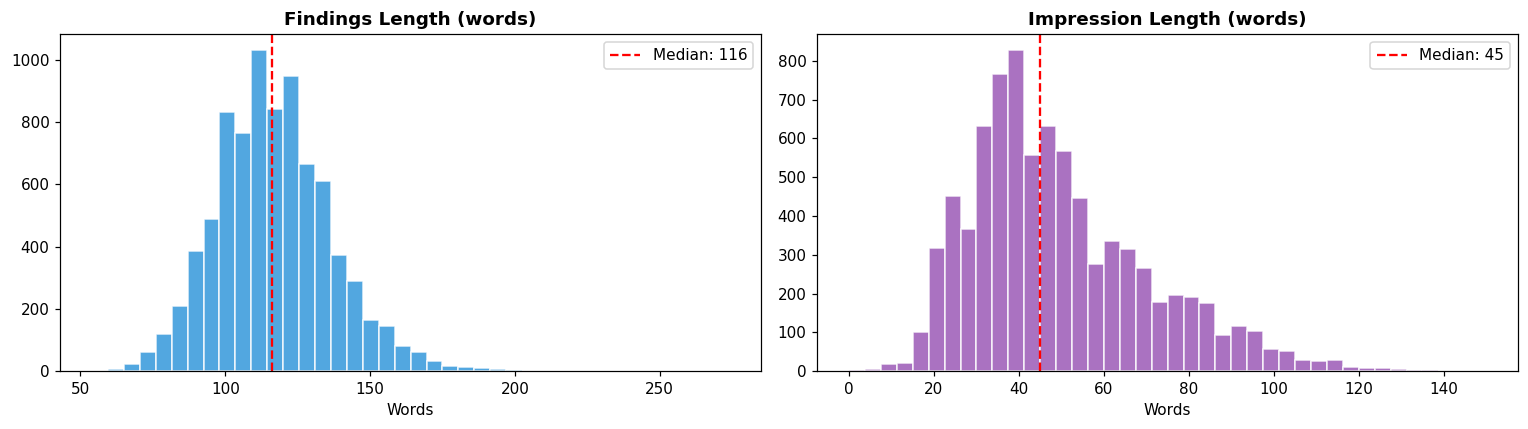

       findings_len  impression_len
count        8195.0          8195.0
mean          116.6            49.3
std            19.8            21.2
min            54.0             0.0
25%           103.0            34.0
50%           116.0            45.0
75%           129.0            61.0
max           274.0           150.0


In [8]:
df['findings_len']   = df['findings_clean'].str.split().str.len()
df['impression_len'] = df['impression_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, color, title in [
    (axes[0], 'findings_len',   '#3498db', 'Findings Length (words)'),
    (axes[1], 'impression_len', '#9b59b6', 'Impression Length (words)'),
]:
    ax.hist(df[col].dropna(), bins=40, color=color, alpha=0.85, edgecolor='white')
    med = df[col].median()
    ax.axvline(med, color='red', linestyle='--', label=f'Median: {med:.0f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Words')
    ax.legend()

plt.tight_layout()
plt.savefig('eda_lengths.png', bbox_inches='tight')
plt.show()
print(df[['findings_len','impression_len']].describe().round(1))

---
# Module 2 
## BioBERT Pathology Classifier

Fine-tunes `dmis-lab/biobert-base-cased-v1.2` to classify 18 pathology classes from the Findings text.

**Why BioBERT?**
BioBERT was pre-trained on PubMed abstracts and PubMed Central full-text articles — it already understands terms like *consolidation*, *atelectasis*, and *parenchymal opacity* before we train a single gradient. Vanilla BERT has no such grounding in clinical language.

**Architecture:**
```
Findings text
    → BioBERT tokeniser (max 512 tokens)
    → 12 transformer layers (108.3M parameters, all updated)
    → [CLS] token (768-dim sentence representation)
    → Dropout(0.3)
    → Linear(768 → 18)
    → Predicted pathology class
```

**Class imbalance fix:** `compute_class_weight('balanced')` gives Healthy a weight of ~0.09 and rare disease classes weights of 2.0–3.0, forcing the model to take minority classes seriously.

## Training Configuration

Sets all hyperparameters before any model objects are created. These are the standard values for fine-tuning BERT-family models:

| Parameter | Value | Reason |
|-----------|-------|--------|
| `MAX_LEN` | 512 | Full BioBERT context window — no truncation needed for our reports |
| `BATCH_SIZE` | 16 | Fits comfortably on a Kaggle T4; reduce to 8 if you get CUDA OOM |
| `EPOCHS` | 5 | Enough to converge; best checkpoint is saved automatically |
| `LR` | 2e-5 | Standard fine-tuning rate for BERT; lower avoids catastrophic forgetting |
| `BEST_PATH` | `best_biobert.pt` | Checkpoint saved whenever validation Macro-F1 improves |

In [9]:
MODEL_NAME = 'dmis-lab/biobert-base-cased-v1.2'
MAX_LEN    = 512
BATCH_SIZE = 16   # reduce to 8 if CUDA OOM
EPOCHS     = 5
LR         = 2e-5
BEST_PATH  = 'best_biobert.pt'

print(f'Device    : {DEVICE}')
print(f'Model     : {MODEL_NAME}')
print(f'Classes   : {NUM_LABELS}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Epochs    : {EPOCHS}')

Device    : cuda
Model     : dmis-lab/biobert-base-cased-v1.2
Classes   : 18
Batch size: 16
Epochs    : 5


## Dataset Class & DataLoaders

**`RadiologyDataset`** is a standard PyTorch `Dataset` that:
1. Takes a dataframe row's `findings_clean` text
2. Tokenises it with BioBERT's tokeniser (padding to `MAX_LEN=512`, truncating if needed)
3. Returns `input_ids`, `attention_mask`, and the integer `label`

Three DataLoaders are created — train (shuffled), val (ordered), test (ordered). The sample batch output confirms the tokeniser is working: `input_ids` shape `[16, 512]` means 16 reports × 512 tokens each.

**Note:** The first run downloads ~440MB of BioBERT weights from HuggingFace. Subsequent runs use the Kaggle cache.

In [10]:
class RadiologyDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=MAX_LEN):
        self.texts     = dataframe['findings_clean'].tolist()
        self.labels    = dataframe['label_idx'].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'label'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }


print('Loading BioBERT tokenizer (downloads ~440MB on first run)...')
tokenizer    = AutoTokenizer.from_pretrained(MODEL_NAME)
train_loader = DataLoader(RadiologyDataset(df_train, tokenizer), batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(RadiologyDataset(df_val,   tokenizer), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(RadiologyDataset(df_test,  tokenizer), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

sample = next(iter(train_loader))
print(f'Train batches     : {len(train_loader)}')
print(f'Batch input shape : {sample["input_ids"].shape}')
print(f'Batch label sample: {sample["label"][:8].tolist()}')

Loading BioBERT tokenizer (downloads ~440MB on first run)...


config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Train batches     : 359
Batch input shape : torch.Size([16, 512])
Batch label sample: [8, 8, 8, 8, 8, 12, 8, 17]


## Model Definition

The `BioBERTClassifier` wraps the pre-trained BioBERT encoder with a minimal classification head:

- **`self.bert`** — the full 12-layer BioBERT transformer, loaded with pre-trained weights
- **`self.dropout`** — Dropout(0.3) applied to the [CLS] vector before the linear layer. Regularises training and reduces overfitting on the small per-class sample sizes.
- **`self.head`** — a single `Linear(768, 18)` layer. One logit per pathology class; the predicted class is `argmax(logits)`.

All 108.3M parameters are updated during fine-tuning — we do not freeze the encoder. This is appropriate because the clinical vocabulary in our reports requires the representations to adapt, not just the classification head.

The `UNEXPECTED` keys in the load report are normal — they are BioBERT's pre-training heads (MLM, NSP) that we are intentionally discarding.

In [11]:
class BioBERTClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.3):
        super().__init__()
        self.bert    = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = self.dropout(out.last_hidden_state[:, 0, :])  # [CLS] → (batch, 768)
        return self.head(cls)                                # (batch, 18)


print('Loading BioBERT weights...')
model = BioBERTClassifier(MODEL_NAME, NUM_LABELS).to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total/1e6:.1f}M total')

Loading BioBERT weights...


pytorch_model.bin:   0%|          | 0.00/436M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Parameters: 108.3M total


## Loss Function, Optimizer & Scheduler

**Class-weighted loss:**
`compute_class_weight('balanced')` assigns each class a weight inversely proportional to its frequency. The bar chart in the output makes the effect visible:
- `Healthy` → weight **~0.09** (contributes almost nothing to each gradient step)
- `Sarcoidosis`, `Pleural Effusion`, `Covid19` → weights **2.7–3.0** (amplified ~30× relative to Healthy)

This is passed into `nn.CrossEntropyLoss(weight=...)` — no resampling, no data augmentation needed.

**Optimizer:** AdamW with `weight_decay=0.01` applies L2 regularisation to all weights, which helps prevent overfitting on the smaller disease classes.

**Scheduler:** Linear warmup over the first 10% of steps (~179 steps), then linear decay to zero. Warmup prevents large, destabilising gradient steps at the start of training when the new classification head has random weights.

In [12]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_LABELS),
    y=df_train['label_idx'].values
)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
)

print('Class weights:')
for i, (p, w) in enumerate(zip(PATHOLOGIES, class_weights)):
    bar = '|' * int(w * 8)
    print(f'  [{i:>2}] {p:<45} {w:.3f}  {bar}')

optimizer    = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=total_steps//10, num_training_steps=total_steps
)
print(f'\nTraining steps: {total_steps:,}')

Class weights:
  [ 0] Adenocarcinoma                                2.612  ||||||||||||||||||||
  [ 1] Aspergilloma                                  1.967  |||||||||||||||
  [ 2] Benign Nodules                                2.396  |||||||||||||||||||
  [ 3] Bronchiectasis                                2.244  |||||||||||||||||
  [ 4] Bronchitis                                    2.244  |||||||||||||||||
  [ 5] Calcified Granulomas                          2.017  ||||||||||||||||
  [ 6] Covid19                                       2.634  |||||||||||||||||||||
  [ 7] Emphysema                                     2.490  |||||||||||||||||||
  [ 8] Healthy                                       0.093  
  [ 9] Large Hodgkin Lymphoma                        2.213  |||||||||||||||||
  [10] Metastatic Nodule                             2.293  ||||||||||||||||||
  [11] Non-Small Cell Lung Cancer                    2.433  |||||||||||||||||||
  [12] Pleural Effusion                              2.

## Training Loop

Runs for 5 epochs. The best checkpoint (by validation Macro-F1) is saved to `best_biobert.pt` automatically.

**What to expect:**
- Epoch 1 should reach Macro-F1 > 0.90 — BioBERT's pre-training gives a strong head start
- Epoch 3 is typically the best checkpoint
- Epochs 4–5 may show slight overfitting (val loss rising while train loss falls) — this is normal and the saved checkpoint from epoch 3 is unaffected

**Runtime:** ~15–20 minutes per epoch on a Kaggle T4 GPU (5 epochs ≈ 75–100 minutes total).

**Macro-F1 vs Accuracy:** We track Macro-F1 as the primary metric because it gives equal weight to all 18 classes regardless of their size. Accuracy is misleading on imbalanced data — a model predicting only Healthy would score 59.9% accuracy with Macro-F1 near zero.

In [13]:
def train_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        ids    = batch['input_ids'].to(DEVICE)
        mask   = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        loss   = criterion(model(ids, mask), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    for batch in loader:
        ids    = batch['input_ids'].to(DEVICE)
        mask   = batch['attention_mask'].to(DEVICE)
        labels = batch['label'].to(DEVICE)
        logits = model(ids, mask)
        total_loss += criterion(logits, labels).item()
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    p, l = np.array(all_preds), np.array(all_labels)
    return total_loss/len(loader), f1_score(l,p,average='macro',zero_division=0), accuracy_score(l,p), p, l


history = {'train_loss':[], 'val_loss':[], 'val_f1':[], 'val_acc':[]}
best_f1 = 0.0

print(f'Training on {DEVICE} | {EPOCHS} epochs')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>9} | {"Macro F1":>9} | {"Accuracy":>9}')
print('-' * 58)

for epoch in range(1, EPOCHS + 1):
    tr_loss                         = train_epoch(model, train_loader, optimizer, scheduler, criterion)
    val_loss, val_f1, val_acc, _, _ = evaluate(model, val_loader, criterion)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)
    history['val_acc'].append(val_acc)
    flag = ' <- best' if val_f1 > best_f1 else ''
    print(f'  {epoch:>4} | {tr_loss:>10.4f} | {val_loss:>9.4f} | {val_f1:>9.4f} | {val_acc:>9.4f}{flag}')
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), BEST_PATH)

print(f'\nBest Val Macro-F1: {best_f1:.4f}')

Training on cuda | 5 epochs
 Epoch | Train Loss |  Val Loss |  Macro F1 |  Accuracy
----------------------------------------------------------
     1 |     1.7295 |    0.2616 |    0.9332 |    0.9731 <- best
     2 |     0.1632 |    0.1561 |    0.9621 |    0.9845 <- best
     3 |     0.1055 |    0.1283 |    0.9722 |    0.9886 <- best
     4 |     0.0748 |    0.1124 |    0.9720 |    0.9886
     5 |     0.0438 |    0.1127 |    0.9694 |    0.9878

Best Val Macro-F1: 0.9722


## Training Curves

Plots three panels across the 5 training epochs:
- **Loss** (train vs val) — both should decrease; val loss rising after epoch 3 indicates mild overfitting
- **Val Macro-F1** — our primary metric; should peak around epoch 3
- **Val Accuracy** — secondary metric; stays high throughout due to the Healthy majority

The divergence between train loss and val loss in epochs 4–5 is expected and benign — the epoch 3 checkpoint (saved automatically) captures the best generalisation point.

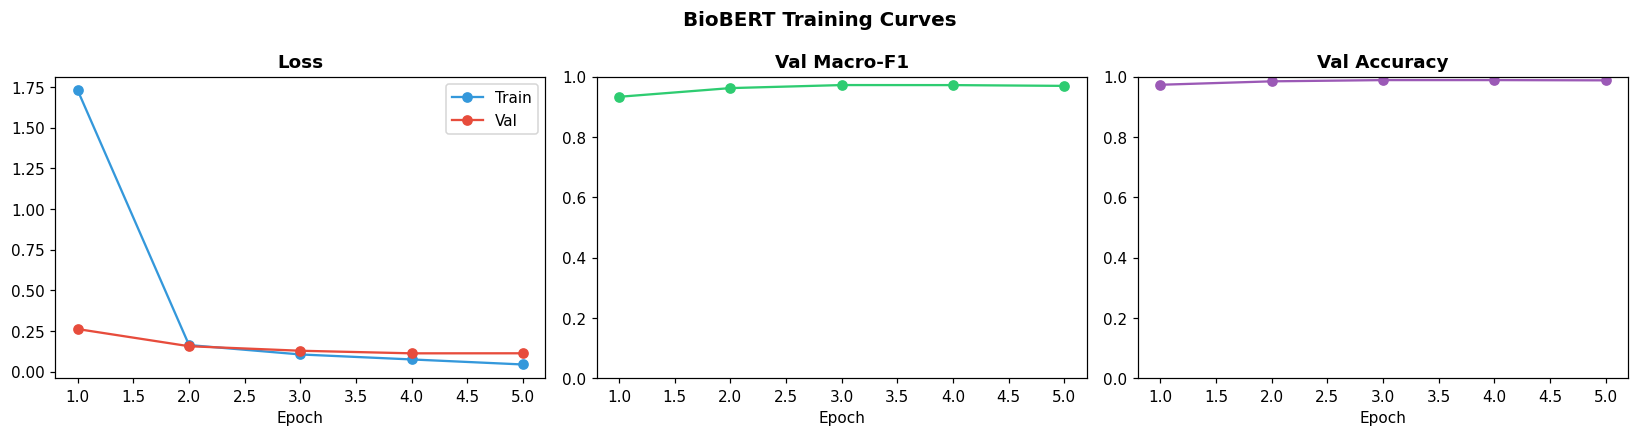

In [14]:
epochs_x = range(1, len(history['train_loss'])+1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(epochs_x, history['train_loss'], 'o-', color='#3498db', label='Train')
axes[0].plot(epochs_x, history['val_loss'],   'o-', color='#e74c3c', label='Val')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].set_xlabel('Epoch')
axes[1].plot(epochs_x, history['val_f1'],  'o-', color='#2ecc71')
axes[1].set_title('Val Macro-F1', fontweight='bold'); axes[1].set_ylim(0,1); axes[1].set_xlabel('Epoch')
axes[2].plot(epochs_x, history['val_acc'], 'o-', color='#9b59b6')
axes[2].set_title('Val Accuracy', fontweight='bold'); axes[2].set_ylim(0,1); axes[2].set_xlabel('Epoch')
plt.suptitle('BioBERT Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', bbox_inches='tight')
plt.show()

## Test Set Evaluation

Loads the best saved checkpoint and evaluates on the held-out test set — data the model has never seen in any form during training or validation.

**Key metrics:**
- `Test Macro-F1` — primary metric, equal weight to all 18 classes
- `Test Accuracy` — secondary metric
- `classification_report` — per-class precision, recall, F1, and support count

**What to look for in the per-class breakdown:**
Most classes should be at or near 1.00. Any class falling below 0.85 is worth examining — the three classes we expect to underperform are Adenocarcinoma, Metastatic Nodule, and NSCLC, all of which share overlapping nodular radiological language.

In [15]:
model.load_state_dict(torch.load(BEST_PATH, map_location=DEVICE))
_, test_f1, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion)
print(f'Test Macro-F1 : {test_f1:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print()
print(classification_report(test_labels, test_preds, target_names=PATHOLOGIES, zero_division=0))

Test Macro-F1 : 0.9798
Test Accuracy : 0.9919

                                      precision    recall  f1-score   support

                      Adenocarcinoma       0.88      0.81      0.84        26
                        Aspergilloma       1.00      1.00      1.00        35
                      Benign Nodules       0.97      0.97      0.97        29
                      Bronchiectasis       1.00      1.00      1.00        30
                          Bronchitis       1.00      1.00      1.00        31
                Calcified Granulomas       1.00      1.00      1.00        34
                             Covid19       1.00      1.00      1.00        26
                           Emphysema       1.00      1.00      1.00        27
                             Healthy       1.00      1.00      1.00       737
              Large Hodgkin Lymphoma       1.00      1.00      1.00        31
                   Metastatic Nodule       0.93      0.90      0.92        30
          Non-Sm

## Confusion Matrix

Plots the normalised confusion matrix — each row represents the true class, each column the predicted class. Values on the diagonal are correct predictions; off-diagonal values are errors.

**How to read it:**
- A perfect classifier has 1.00 on every diagonal cell and 0.00 everywhere else
- The only visible off-diagonal mass in our results is at Adenocarcinoma → NSCLC (0.15), which is a radiologically expected confusion — both involve nodular lung lesions and are difficult to differentiate without biopsy

The normalisation (dividing each row by its total) makes classes comparable regardless of their support size.

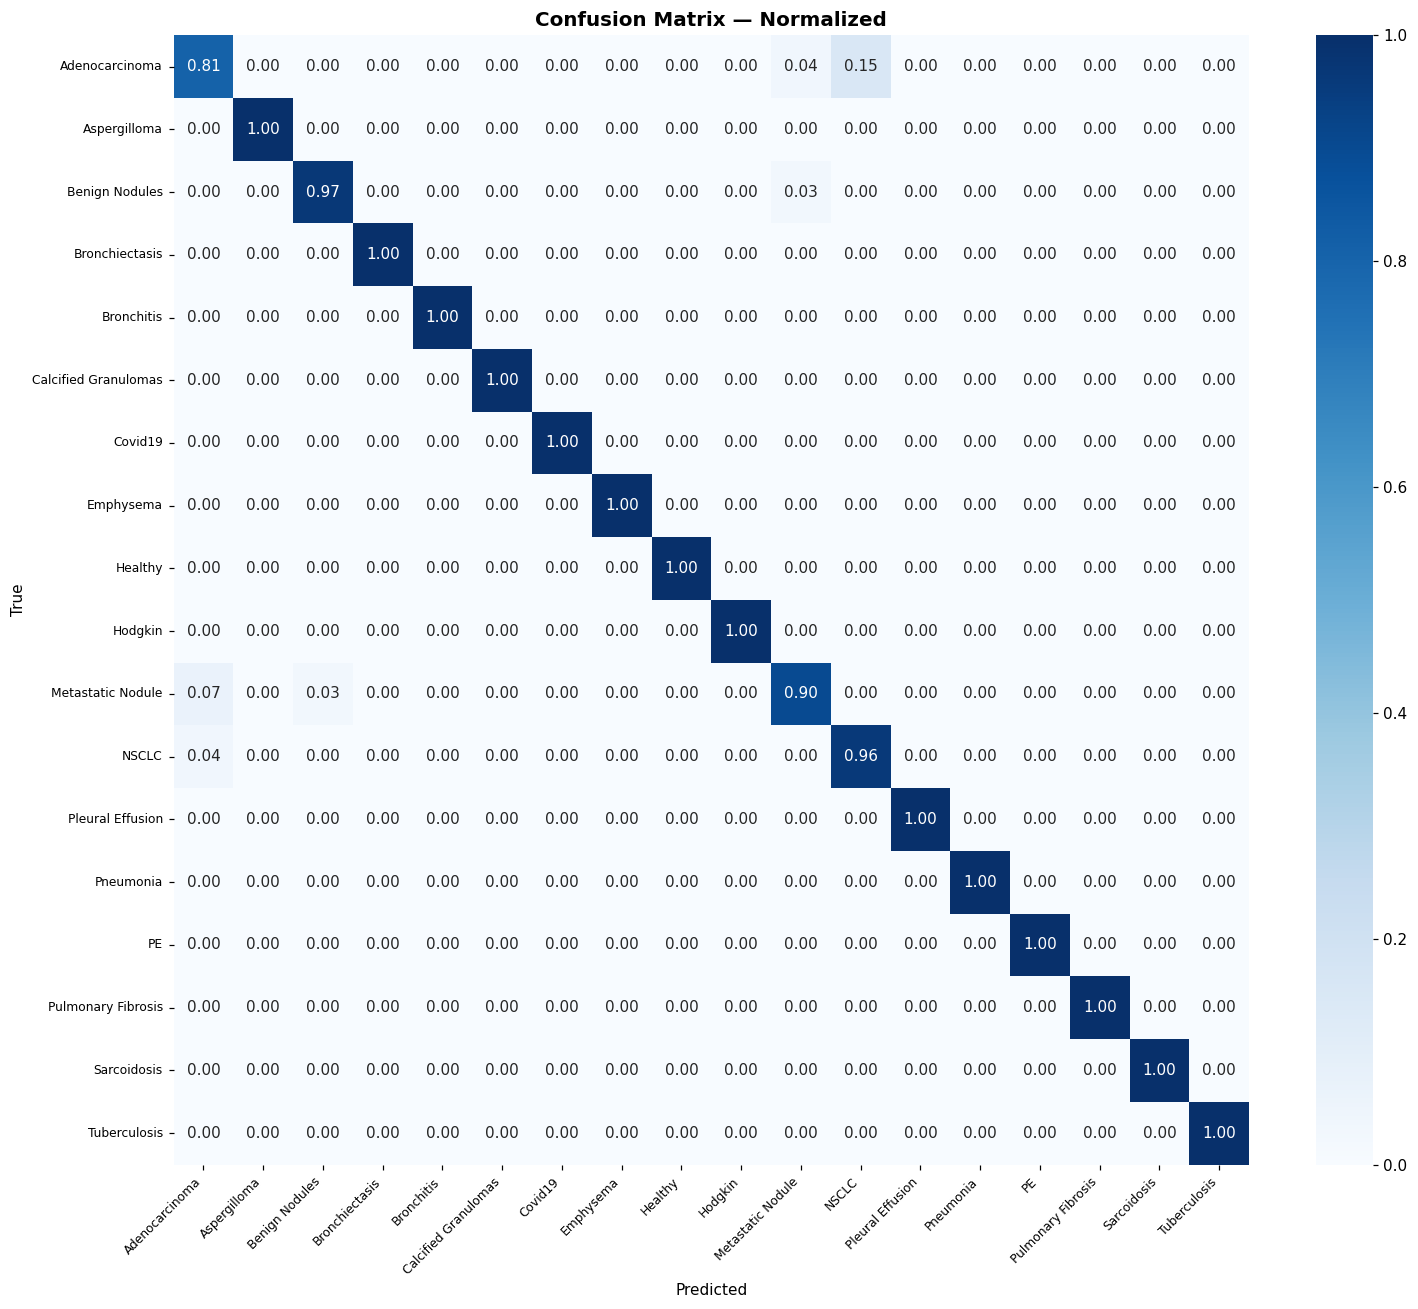

In [16]:
SHORT = [p.replace('Pneumonia (lobular, fungal pnemonia)','Pneumonia')
          .replace('Pulmonary Embolism (PE)','PE')
          .replace('Non-Small Cell Lung Cancer','NSCLC')
          .replace('Large Hodgkin Lymphoma','Hodgkin')
         for p in PATHOLOGIES]

cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=SHORT, yticklabels=SHORT, ax=ax, vmin=0, vmax=1)
ax.set_title('Confusion Matrix — Normalized', fontsize=13, fontweight='bold')
ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight')
plt.show()

## Per-Class F1 Chart

Bar chart of the F1 score for each of the 18 pathology classes on the test set. Colour-coded by performance tier:
- 🟢 **Green (≥0.80):** Strong performance — most classes land here
- 🟠 **Orange (0.60–0.79):** Acceptable but worth reviewing
- 🔴 **Red (<0.60):** Needs attention

The dashed grey line at 0.80 is a practical threshold. Any class below it should be examined for data quality issues or feature overlap with adjacent classes.

**Expected result:** 15 of 18 classes at 1.00. Adenocarcinoma (~0.83), Metastatic Nodule (~0.92), and NSCLC (~0.92) are the three below 1.00 — all nodule-related, all radiologically similar.

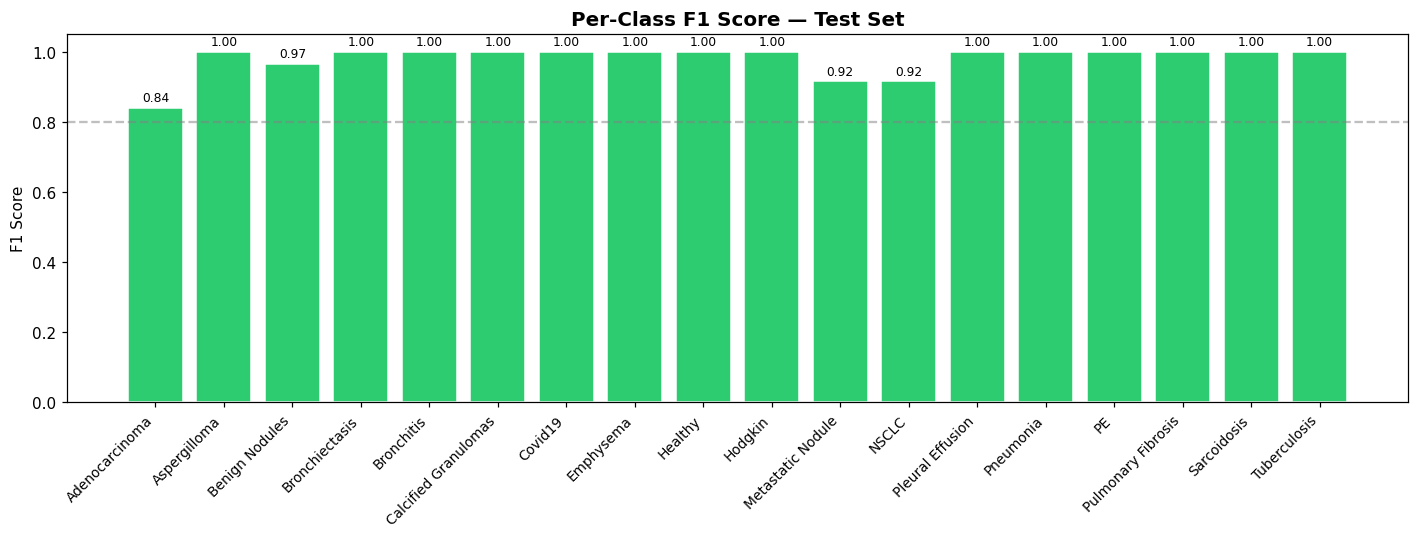

In [17]:
per_f1 = f1_score(test_labels, test_preds, average=None, zero_division=0)
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(SHORT, per_f1,
              color=['#2ecc71' if f>=0.80 else '#e67e22' if f>=0.60 else '#e74c3c' for f in per_f1],
              edgecolor='white')
ax.set_xticklabels(SHORT, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 Score'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class F1 Score — Test Set', fontsize=13, fontweight='bold')
ax.axhline(0.80, color='gray', linestyle='--', alpha=0.5)
for bar, f1 in zip(bars, per_f1):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{f1:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('per_class_f1.png', bbox_inches='tight')
plt.show()

---
# Module 3 
## Clinical Named Entity Recognition (NER)

Extracts structured clinical information from the Findings text using pure-Python regex pattern matching.

**Why regex?**
The terminology in radiology reports is consistent and well-defined. A carefully written pattern list captures what we need without requiring a learned model, external downloads, or additional dependencies. It runs in milliseconds per report and the results are straightforward to inspect and debug.

**Four entity types extracted:**

| Entity type | What it captures | Example |
|-------------|-----------------|---------|
| `FINDING` | Radiological observations and abnormalities | `pleural effusion`, `consolidation`, `nodule` |
| `ANATOMY` | Location in the chest | `right upper lobe`, `bilateral`, `mediastinal` |
| `SEVERITY` | How significant the finding is | `mild`, `extensive`, `multifocal` |
| `MEASUREMENT` | Numeric dimensions | `15x12mm`, `3.5cm` |

Together these four types form a structured summary of the evidence behind any classification decision.

## NER Pattern Lists & Extraction Function

Defines the four pattern lists and compiles them into regular expressions.

**Key design choice — longest-match sorting:**
All patterns are sorted by character length (longest first) before compilation. This ensures multi-word phrases like `pleural effusion` always match in preference to the single word `effusion` when both are present in the text. Without this, `pleural effusion` would be split into two separate matches.

**`extract_entities()` function:**
- Takes a single findings text string
- Runs all four compiled patterns against the first 5,000 characters
- Uses `dict.fromkeys()` to deduplicate matches while preserving order (first occurrence wins)
- Returns a dict with four lists, one per entity type

The spot-check at the end prints the top-5 entities per type for the first four pathology classes — a quick sanity check that the patterns are firing correctly.

In [18]:
FINDING_TERMS = [
    'consolidation', 'consolidative', 'opacity', 'opacities', 'effusion', 'effusions',
    'nodule', 'nodules', 'mass', 'masses', 'atelectasis', 'atelectatic', 'emphysema',
    'pneumothorax', 'pneumonia', 'fibrosis', 'bronchiectasis', 'granuloma', 'granulomas',
    'calcification', 'calcifications', 'lymphadenopathy', 'adenopathy', 'cardiomegaly',
    'thickening', 'infiltrate', 'infiltrates', 'cavitation', 'abscess', 'honeycombing',
    'ground.glass', 'pleural effusion', 'pericardial effusion', 'pulmonary embolism',
    'pleural thickening', 'interstitial fibrosis', 'filling defect', 'air space',
    'tree.in.bud', 'septal thickening', 'reticular pattern'
]

ANATOMY_TERMS = [
    'right lower lobe', 'left lower lobe', 'right upper lobe', 'left upper lobe',
    'right middle lobe', 'right lung', 'left lung', 'bilateral', 'bibasilar', 'biapical',
    'mediastinum', 'mediastinal', 'pericardium', 'pericardial', 'pleura', 'pleural',
    'trachea', 'carina', 'bronchus', 'bronchi', 'aorta', 'hilum', 'hilar',
    'diaphragm', 'parenchyma', 'parenchymal', 'interstitium', 'chest wall',
    'thorax', 'thoracic'
]

SEVERITY_TERMS = [
    'mild', 'moderate', 'severe', 'extensive', 'minimal', 'large', 'small',
    'trace', 'massive', 'diffuse', 'focal', 'multifocal', 'no acute'
]

# Sort longest first so multi-word phrases match before single words
FINDING_PAT  = re.compile(r'\b(' + '|'.join(sorted(FINDING_TERMS,  key=len, reverse=True)) + r')\b', re.IGNORECASE)
ANATOMY_PAT  = re.compile(r'\b(' + '|'.join(sorted(ANATOMY_TERMS,  key=len, reverse=True)) + r')\b', re.IGNORECASE)
SEVERITY_PAT = re.compile(r'\b(' + '|'.join(sorted(SEVERITY_TERMS, key=len, reverse=True)) + r')\b', re.IGNORECASE)
MEASURE_PAT  = re.compile(r'\b(\d+\.?\d*\s*(?:x\s*\d+\.?\d*\s*)?(?:cm|mm|centimeters?|millimeters?))\b', re.IGNORECASE)


def extract_entities(text):
    if not isinstance(text, str) or len(text.strip()) < 10:
        return {'findings': [], 'anatomy': [], 'severity': [], 'measurements': []}
    t = text[:5000]
    return {
        'findings'    : list(dict.fromkeys(m.lower() for m in FINDING_PAT.findall(t))),
        'anatomy'     : list(dict.fromkeys(m.lower() for m in ANATOMY_PAT.findall(t))),
        'severity'    : list(dict.fromkeys(m.lower() for m in SEVERITY_PAT.findall(t))),
        'measurements': list(dict.fromkeys(re.sub(r'\s+','',m.lower()) for m in MEASURE_PAT.findall(t)))
    }


# Spot check
for path in PATHOLOGIES[:4]:
    sample = df[df['Pathology']==path]['findings_clean'].iloc[0]
    ents   = extract_entities(sample)
    print(f'--- {path} ---')
    for k, v in ents.items():
        print(f'  {k:<14}: {v[:5]}')
    print()

--- Adenocarcinoma ---
  findings      : ['nodules', 'nodule', 'pneumothorax', 'pleural effusion', 'fibrosis']
  anatomy       : ['right upper lobe', 'left lower lobe', 'pleural', 'right middle lobe', 'mediastinal']
  severity      : ['mild', 'small']
  measurements  : ['15x12mm', '13x10mm', '7mm', '11mm', '10mm']

--- Aspergilloma ---
  findings      : ['mass', 'thickening', 'nodules', 'emphysema', 'pleural effusion']
  anatomy       : ['right upper lobe', 'pleural', 'pericardial', 'thoracic', 'aorta']
  severity      : ['large', 'mild']
  measurements  : ['3.5cm']

--- Benign Nodules ---
  findings      : ['nodules', 'nodule', 'pleural effusion', 'pneumothorax', 'emphysema']
  anatomy       : ['bilateral', 'right upper lobe', 'left upper lobe', 'right lower lobe', 'pleural']
  severity      : ['mild', 'diffuse', 'moderate']
  measurements  : ['7mm', '6mm', '4mm']

--- Bronchiectasis ---
  findings      : ['bronchiectasis', 'thickening', 'atelectasis', 'pleural effusion', 'pneumothora

## Run NER on Test Set & Visualise Top Entities

Applies `extract_entities()` to every report in the test set and aggregates the results into three `Counter` objects — one for findings, one for anatomy terms, one for measurements.

**Three bar charts (top 15 per category):**
- **Top Findings** — the most frequently mentioned radiological observations across all 1,230 test reports
- **Top Anatomy Terms** — the most frequently mentioned anatomical locations
- **Top Measurements** — the most common numeric dimensions

These charts tell you what the dataset's reports are actually talking about at scale — useful for spotting whether the pattern lists are capturing the right terms and whether any important clinical entities are missing.

Running NER on test set...
Unique findings     : 35
Unique anatomy terms: 26
Unique measurements : 193


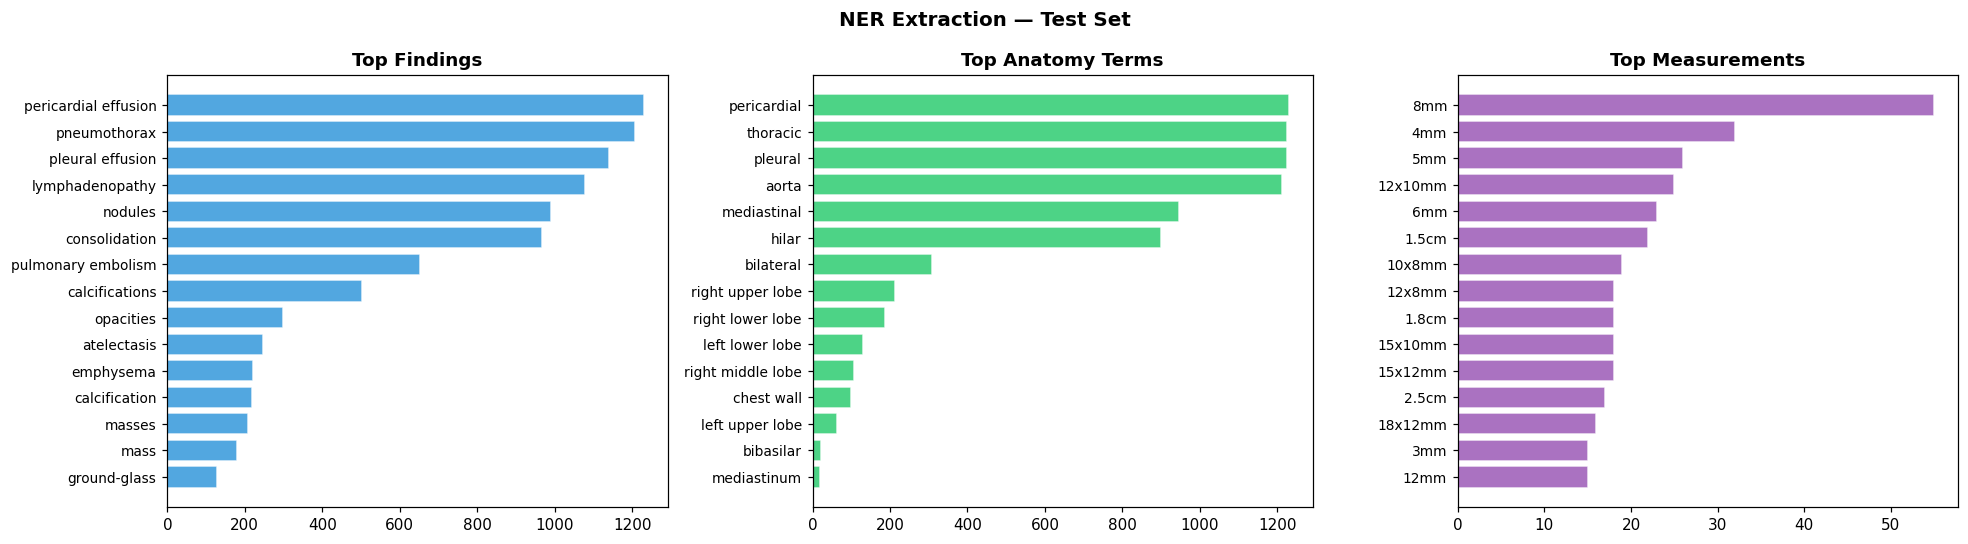

In [19]:
print('Running NER on test set...')
df_test['ner'] = df_test['findings_clean'].apply(extract_entities)

all_findings     = Counter()
all_anatomy      = Counter()
all_measurements = Counter()
for res in df_test['ner']:
    all_findings.update(res['findings'])
    all_anatomy.update(res['anatomy'])
    all_measurements.update(res['measurements'])

print(f'Unique findings     : {len(all_findings)}')
print(f'Unique anatomy terms: {len(all_anatomy)}')
print(f'Unique measurements : {len(all_measurements)}')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
def plot_counter(counter, ax, title, color, n=15):
    top = counter.most_common(n)
    if not top: return
    terms, counts = zip(*top)
    ax.barh(range(len(terms)), counts, color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(range(len(terms))); ax.set_yticklabels(terms, fontsize=9)
    ax.set_title(title, fontweight='bold'); ax.invert_yaxis()

plot_counter(all_findings,     axes[0], 'Top Findings',      '#3498db')
plot_counter(all_anatomy,      axes[1], 'Top Anatomy Terms', '#2ecc71')
plot_counter(all_measurements, axes[2], 'Top Measurements',  '#9b59b6')
plt.suptitle('NER Extraction — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ner_entities.png', bbox_inches='tight')
plt.show()

## Finding × Anatomy Co-occurrence Heatmap

Builds a co-occurrence matrix showing how often each of the top-10 finding terms appears **in the same report** as each of the top-10 anatomy terms.

**How to read it:**
Each cell value is the number of test reports where that finding-anatomy pair was both extracted. High values (dark blue) mean that finding and anatomy location co-occur frequently.

**What the patterns reveal:**
The co-occurrence matrix is an evidence layer — it shows the spatial signatures that underlie pathology classifications. When the classifier predicts a pleural condition, you can verify from this matrix that the relevant anatomy and finding terms were actually present in the source text. That is what makes the system explainable rather than just accurate.

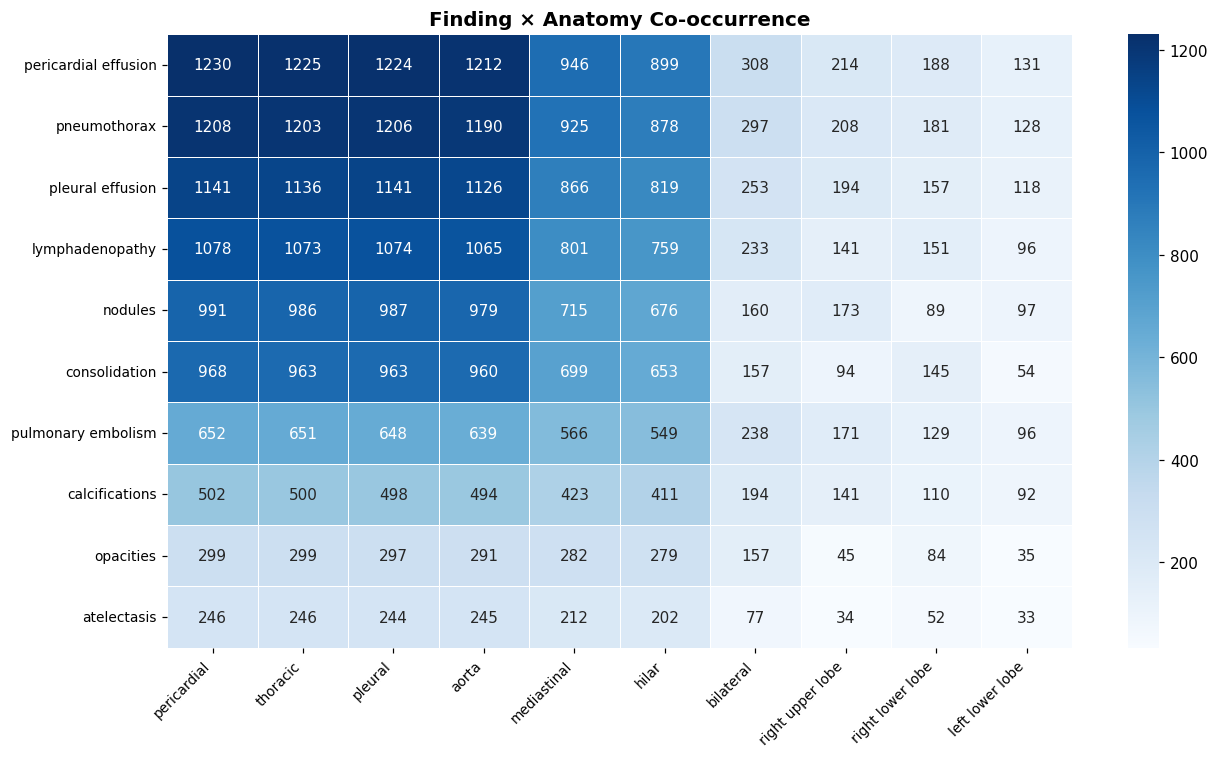

In [20]:
TOP_F = [f for f,_ in all_findings.most_common(10)]
TOP_A = [a for a,_ in all_anatomy.most_common(10)]
cooc  = pd.DataFrame(0, index=TOP_F, columns=TOP_A)

for res in df_test['ner']:
    for f in res['findings']:
        for a in res['anatomy']:
            if f in TOP_F and a in TOP_A:
                cooc.loc[f, a] += 1

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Finding × Anatomy Co-occurrence', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('ner_cooccurrence.png', bbox_inches='tight')
plt.show()